# 03 Feedforward Neural Network

Train a regularized return regressor, compare it with linear regression and alternate depths, and evaluate a long-or-cash signal net of transaction costs.

In [1]:
from pathlib import Path
import copy
import random
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.utils.tensorboard import SummaryWriter

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FAST_MODE = True
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
RUNS_DIR = PROJECT_ROOT / "runs" / "feedforward_nn"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RUNS_DIR.mkdir(parents=True, exist_ok=True)
print("Device:", DEVICE)

Device: cuda


## Load the temporal splits

In [2]:
train_df = pd.read_csv(PROCESSED_DIR / "train.csv", parse_dates=["Date"])
val_df = pd.read_csv(PROCESSED_DIR / "val.csv", parse_dates=["Date"])
test_df = pd.read_csv(PROCESSED_DIR / "test.csv", parse_dates=["Date"])
FEATURE_COLS = joblib.load(MODELS_DIR / "feature_cols.joblib")
TARGET_COL = "target_next_day_logreturn"


class MarketDataset(Dataset):
    def __init__(self, frame):
        self.x = torch.tensor(frame[FEATURE_COLS].to_numpy(np.float32))
        self.y = torch.tensor(frame[TARGET_COL].to_numpy(np.float32)).unsqueeze(1)
    def __len__(self): return len(self.x)
    def __getitem__(self, index): return self.x[index], self.y[index]


BATCH_SIZE = 512
train_loader = DataLoader(MarketDataset(train_df), batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(MarketDataset(val_df), batch_size=BATCH_SIZE)
test_loader = DataLoader(MarketDataset(test_df), batch_size=BATCH_SIZE)
print(f"Features: {len(FEATURE_COLS)} | Train: {len(train_df):,} | Validation: {len(val_df):,} | Test: {len(test_df):,}")

Features: 12 | Train: 172,673 | Validation: 38,100 | Test: 38,100


## Define and train the required network

In [3]:
class FeedForwardNN(nn.Module):
    def __init__(self, input_size, hidden_sizes=(128, 64, 32), dropout=0.3):
        super().__init__()
        layers, previous = [], input_size
        for hidden in hidden_sizes:
            layers.extend([nn.Linear(previous, hidden), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Dropout(dropout)])
            previous = hidden
        layers.append(nn.Linear(previous, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, inputs): return self.network(inputs)


def average_loss(model, loader, criterion):
    model.eval(); total, rows = 0.0, 0
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
            total += criterion(model(x_batch), y_batch).item() * len(x_batch)
            rows += len(x_batch)
    return total / rows


def train_model(model, name, epochs=100, patience=10):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    writer = SummaryWriter(str(RUNS_DIR / name))
    best_loss, best_state, best_epoch, stale = float("inf"), copy.deepcopy(model.state_dict()), 0, 0
    history = {"train_loss": [], "val_loss": []}
    for epoch in range(1, epochs + 1):
        model.train(); total, rows = 0.0, 0
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad(); loss = criterion(model(x_batch), y_batch); loss.backward(); optimizer.step()
            total += loss.item() * len(x_batch); rows += len(x_batch)
        train_loss = total / rows
        val_loss = average_loss(model, val_loader, criterion)
        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        writer.add_scalar("Loss/Train", train_loss, epoch); writer.add_scalar("Loss/Validation", val_loss, epoch)
        if val_loss < best_loss:
            best_loss, best_state, best_epoch, stale = val_loss, copy.deepcopy(model.state_dict()), epoch, 0
        else: stale += 1
        if epoch == 1 or epoch % 10 == 0: print(f"Epoch {epoch:3d} | train={train_loss:.8f} | val={val_loss:.8f}")
        if stale >= patience: break
    writer.close(); model.load_state_dict(best_state)
    history.update(best_epoch=best_epoch, best_val_loss=best_loss, stopped_epoch=len(history["train_loss"]))
    return model, history


primary_model = FeedForwardNN(len(FEATURE_COLS)).to(DEVICE)
primary_model, primary_history = train_model(primary_model, "3_layer_128_64_32", epochs=100, patience=10)
torch.save({"model_state_dict": primary_model.state_dict(), "input_size": len(FEATURE_COLS), "hidden_sizes": [128, 64, 32], "dropout": 0.3}, MODELS_DIR / "feedforward_nn_step3.pt")
print("Saved primary model.")

Epoch   1 | train=0.01243202 | val=0.00080449


Epoch  10 | train=0.00038958 | val=0.00056226


Epoch  20 | train=0.00038745 | val=0.00055643


Saved primary model.


## Inspect training and validation loss

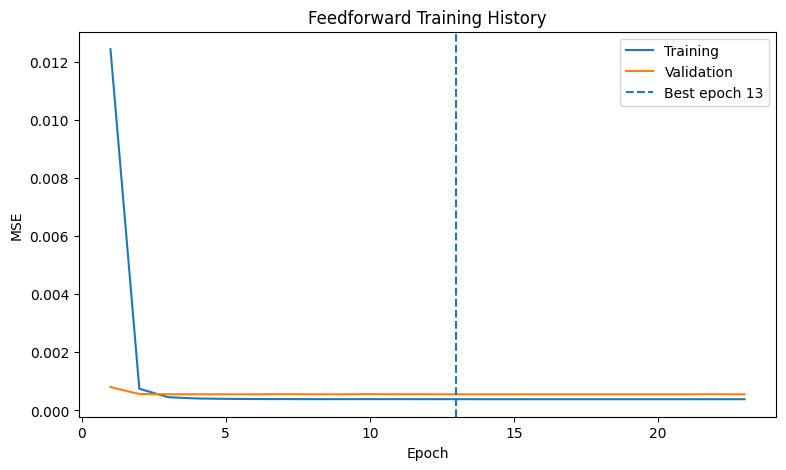

In [4]:
epochs = np.arange(1, len(primary_history["train_loss"]) + 1)
plt.figure(figsize=(9, 5))
plt.plot(epochs, primary_history["train_loss"], label="Training")
plt.plot(epochs, primary_history["val_loss"], label="Validation")
plt.axvline(primary_history["best_epoch"], linestyle="--", label=f"Best epoch {primary_history['best_epoch']}")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.title("Feedforward Training History"); plt.legend(); plt.show()

## Evaluate predictions net of 10 basis point transaction costs

In [5]:
def predict(model, loader):
    model.eval(); predictions, targets = [], []
    with torch.no_grad():
        for x_batch, y_batch in loader:
            predictions.append(model(x_batch.to(DEVICE)).squeeze(1).cpu().numpy())
            targets.append(y_batch.squeeze(1).numpy())
    return np.concatenate(predictions), np.concatenate(targets)


def annualized_sharpe(returns):
    returns = np.asarray(returns, float)
    return returns.mean() / returns.std(ddof=1) * np.sqrt(252) if len(returns) > 1 and returns.std(ddof=1) > 0 else np.nan


def evaluate_predictions(y_true, y_pred, metadata, transaction_cost_bps=10.0):
    strategy = metadata[["Date", "Ticker"]].copy().reset_index(drop=True)
    strategy["actual_return"], strategy["prediction"] = y_true, y_pred
    strategy = strategy.sort_values(["Ticker", "Date"]).reset_index(drop=True)
    strategy["position"] = (strategy["prediction"] > 0).astype(float)
    previous = strategy.groupby("Ticker")["position"].shift(fill_value=0.0)
    strategy["trade"] = (strategy["position"] - previous).abs()
    strategy["strategy_return"] = strategy["position"] * strategy["actual_return"] - strategy["trade"] * transaction_cost_bps / 10_000
    daily = strategy.groupby("Date")["strategy_return"].mean().sort_index()
    return {
        "MSE": mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "Directional Accuracy (%)": 100 * np.mean(np.sign(y_true) == np.sign(y_pred)),
        "Sharpe Ratio (net 10 bps)": annualized_sharpe(daily),
        "Average Daily Turnover": strategy.groupby("Date")["trade"].mean().mean(),
    }


nn_predictions, nn_targets = predict(primary_model, test_loader)
nn_metrics = evaluate_predictions(nn_targets, nn_predictions, test_df)
display(pd.DataFrame([{"Model": "Feedforward NN", **nn_metrics}]).set_index("Model"))

,MSE,MAE,Directional Accuracy (%),Sharpe Ratio (net 10 bps),Average Daily Turnover
Model,,,,,
Feedforward NN,0.000298,0.011645,52.081365,1.171226,0.024016


## Compare with linear regression

In [6]:
linear_model = LinearRegression().fit(train_df[FEATURE_COLS], train_df[TARGET_COL])
linear_predictions = linear_model.predict(test_df[FEATURE_COLS])
linear_metrics = evaluate_predictions(test_df[TARGET_COL].to_numpy(), linear_predictions, test_df)
joblib.dump(linear_model, MODELS_DIR / "linear_regression_step3.joblib")
comparison = pd.DataFrame([
    {"Model": "Feedforward NN", **nn_metrics},
    {"Model": "Linear Regression", **linear_metrics},
]).set_index("Model")
display(comparison)
print("Neural network beats baseline MSE:", nn_metrics["MSE"] < linear_metrics["MSE"])

,MSE,MAE,Directional Accuracy (%),Sharpe Ratio (net 10 bps),Average Daily Turnover
Model,,,,,
Feedforward NN,0.000298,0.011645,52.081365,1.171226,0.024016
Linear Regression,0.000298,0.011677,50.947507,0.600083,0.198504


Neural network beats baseline MSE: True


## Compare network depth

The required 3-layer model keeps the full early-stopping budget. `FAST_MODE` shortens only the extra 2-layer and 5-layer comparison runs.

In [7]:
architectures = {"2-layer": (128, 64), "3-layer": (128, 64, 32), "5-layer": (128, 64, 32, 16, 8)}
models = {"3-layer": primary_model}; histories = {"3-layer": primary_history}; metrics = {"3-layer": nn_metrics}
for name in ["2-layer", "5-layer"]:
    torch.manual_seed(SEED)
    candidate = FeedForwardNN(len(FEATURE_COLS), architectures[name]).to(DEVICE)
    candidate, history = train_model(candidate, name, epochs=12 if FAST_MODE else 100, patience=3 if FAST_MODE else 10)
    predictions, targets = predict(candidate, test_loader)
    models[name], histories[name], metrics[name] = candidate, history, evaluate_predictions(targets, predictions, test_df)

rows = []
for name in architectures:
    history = histories[name]; best = history["best_epoch"] - 1
    rows.append({"Architecture": name, "Training MSE": history["train_loss"][best], "Validation MSE": history["best_val_loss"], **metrics[name]})
architecture_results = pd.DataFrame(rows).set_index("Architecture")
display(architecture_results)
print("Lowest test MSE:", architecture_results["MSE"].idxmin())

Epoch   1 | train=0.02341169 | val=0.00075000


Epoch   1 | train=0.04857229 | val=0.00711367


Epoch  10 | train=0.00039480 | val=0.00057269


,Training MSE,Validation MSE,MSE,MAE,Directional Accuracy (%),Sharpe Ratio (net 10 bps),Average Daily Turnover
Architecture,,,,,,,
2-layer,0.000393,0.000558,0.000299,0.011681,51.370079,0.818654,0.124672
3-layer,0.000388,0.000556,0.000298,0.011645,52.081365,1.171226,0.024016
5-layer,0.000393,0.000556,0.000297,0.011629,51.532808,0.966772,0.043701


Lowest test MSE: 5-layer


## TensorBoard

In [8]:
print("TensorBoard log directory:", RUNS_DIR.resolve())
print(f"Run: tensorboard --logdir {RUNS_DIR.resolve()}")

TensorBoard log directory: C:\Users\ashym\Documents\GitHub\jarvis_data_eng_YashMehrotra\ml_2\runs\feedforward_nn
Run: tensorboard --logdir C:\Users\ashym\Documents\GitHub\jarvis_data_eng_YashMehrotra\ml_2\runs\feedforward_nn
